In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas import DataFrame, Series, Index

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.dummy import DummyRegressor

In [2]:
# loading of dataset
df = pd.read_csv("../data/house_train.csv")

In [3]:
# split dataset on features and target (SalePrice)
X = df.drop(columns="SalePrice")
y = df["SalePrice"]

In [4]:
# features that will not take part in the training, root cause in EDA 
drop_features = [
    "Id", "Utilities", "Street", "PoolQC", "MiscFeature", "Alley", "Fence",
    "MiscVal", "LotFrontage", "1stFlrSF", "2ndFlrSF", "BsmtFinSF1",
    "BsmtFinSF2", "BsmtUnfSF", "GarageArea", "YearBuilt", "YearRemodAdd",
    "GarageYrBlt", "YrSold", "TotRmsAbvGrd", "KitchenAbvGr", "BedroomAbvGr",
    "FullBath", "Condition2", "RoofMatl", "Heating",
] 

# 1. Log transformation (log1p)
log_features = [
    "LotArea",
    "GrLivArea",
    "TotalBsmtSF",
    "MasVnrArea",
    "OpenPorchSF",
    "WoodDeckSF",
    "EnclosedPorch",
    "ScreenPorch",
]

zero_inflated_features = [
    "MasVnrArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "LowQualFinSF",
    "BsmtHalfBath",
]

ordinal_mapping = {
    "ExterQual":   ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond":   ["Po", "Fa", "TA", "Gd", "Ex"],
    "HeatingQC":   ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],

    "BsmtQual":     ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond":     ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["NA", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],

    "GarageQual":   ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond":   ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish": ["NA", "Unf", "RFn", "Fin"],

    "FireplaceQu": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "PavedDrive": ["N", "P", "Y"],
    "OverallQual": list(range(1, 11)),
    "OverallCond": list(range(1, 11)),
}

nominal_features = [
    "MSSubClass",
    "MSZoning",
    "Neighborhood",
    "Condition1",
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "Foundation",
    "GarageType",
    "SaleType",
    "SaleCondition",
    "CentralAir",
    "Exterior1st",
    "Exterior2nd",
    "LandContour",
    "LotConfig",
    "MasVnrType",
    "Electrical",
]

numeric_no_log_features = [
    "GarageCars",
    "Fireplaces",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MoSold",
]

In [5]:
# custom transformer for creating additional binary features
class ZeroInflationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, prefix="has_"):
        self.prefix = prefix

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        self.is_fitted_ = True
        return self

    def transform(self, X):
        X = np.asarray(X)
        indicator = (X != 0).astype(int)
        return np.hstack([X, indicator])

    def get_feature_names_out(self, input_features=None):
        feats = self.feature_names_in_ if input_features is None else np.array(input_features, dtype=object)
        return np.array([f"{self.prefix}{c}" for c in feats], dtype=object)

In [6]:
# custom transformer for creating additional features
class DiffTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, x1, x2, name):
        self.x1 = x1
        self.x2 = x2
        self.name = name

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return (X[self.x1] - X[self.x2]).to_frame(self.name)

    def get_feature_names_out(self, input_features=None):
        return np.array([self.name], dtype=object)

In [7]:
# pipeline for numeric
numeric_pipeline = Pipeline(steps=[
    ('imputed', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# pipeline for skewed numeric
skewed_numeric_pipeline = Pipeline(steps=[
    ('imputed', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),
    ('scaler', StandardScaler())
])

# pipeline for ordinal categorical
ordinal_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=list(ordinal_mapping.values()), handle_unknown="error"))
])

# pipeline for nominal categorical
nominal_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# pipeline for binary features with prefix has
zero_inflated_pipeline = Pipeline(steps=[
    ('imputed', SimpleImputer(strategy='median')),
    ("has_feature", ZeroInflationTransformer()),
])

# add new features
age_house_transformer = DiffTransformer(x1='YrSold', x2='YearBuilt', name='AgeHouse')
age_remodel_transformer = DiffTransformer(x1='YrSold', x2='YearRemodAdd', name='AgeRemodel')
age_garage_transformer = DiffTransformer(x1='YrSold', x2='GarageYrBlt', name='AgeGarage')

ages_pipeline = Pipeline(steps=[
    ("age", ColumnTransformer(transformers=[
        ("age_house", age_house_transformer, ['YrSold', 'YearBuilt']),
        ("age_remodel", age_remodel_transformer, ['YrSold', 'YearRemodAdd']),
        ("age_garage", age_garage_transformer, ['YrSold', 'GarageYrBlt']),
    ], remainder='drop')),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

In [8]:
preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_no_log_features),
    ("skewed_numeric", skewed_numeric_pipeline, log_features),
    ("ages", ages_pipeline, ['YrSold', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt']), 
    ("zero", zero_inflated_pipeline, zero_inflated_features),
    ("ordinal_cat", ordinal_categorical_pipeline, list(ordinal_mapping.keys())),
    ("nomin_cat", nominal_categorical_pipeline, nominal_features),
], remainder="drop")

In [9]:
def make_split(X, y, test_size=0.2, random_state=42) -> list:
   return train_test_split(X, y, test_size=test_size, random_state=random_state)

In [10]:
# split the dataset into train and validate 
X_train, X_valid, y_train, y_valid = make_split(X, y)

In [11]:
# register pipelines and baseline model
baseline_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

In [12]:
# add transformer for applying log transformation for target
model = TransformedTargetRegressor(
    regressor=baseline_model,
    func=np.log1p,
    inverse_func=np.expm1
)

In [13]:
# apply cross-validation for best training
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')

In [15]:
print(f"RMSE by folds {-scores}")
print(f"RMSE {-scores.mean()}")

RMSE by folds [27298.89803839 32333.56024995 39819.19042359 23754.9676696
 22807.79301574]
RMSE 29202.88187945408


In [16]:
model.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...egression())])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('skewed_numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. Whe

In [17]:
y_pred = model.predict(X_valid)

In [18]:
rmse_model = root_mean_squared_error(y_valid, y_pred)
rmse_model

26611.982649567275

## Baseline comparison

We compare our model against a naive baseline (DummyRegressor with median strategy).
This helps us verify that the model actually learns meaningful signal from features.

In [19]:
# dummy check, strategy = median, because target has right-skew
dummy_model = DummyRegressor(strategy='median')

In [20]:
dummy_model.fit(X_train, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'median'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [21]:
dummy_pred = dummy_model.predict(X_valid)

In [22]:
rmse_dummy = root_mean_squared_error(y_valid, dummy_pred)
rmse_dummy

88667.16750592619

In [23]:
results = pd.DataFrame({
    "Model": ["Dummy (median)", "Linear Regression"],
    "RMSE": [rmse_dummy, rmse_model]
})
results

,Model,RMSE
0,Dummy (median),88667.167506
1,Linear Regression,26611.982650


The linear model improves RMSE from **88,667** to **26,611**,
which corresponds to a **~70%** relative improvement over the naive baseline.
This confirms that the feature set provides a meaningful predictive signal.

### Residual Analysis

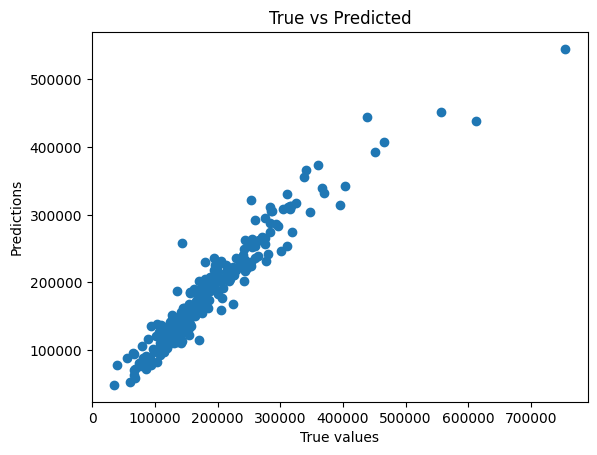

In [24]:
# visualization of interaction True and Predicted
plt.figure()
plt.scatter(y_valid, y_pred)
plt.xlabel("True values")
plt.ylabel("Predictions")
plt.title("True vs Predicted")
plt.show()

**True vs Predicted** — The model works well in the middle price segment, but it systematically underestimates expensive houses (above 400k). A linear model cannot properly capture the tail of the distribution.

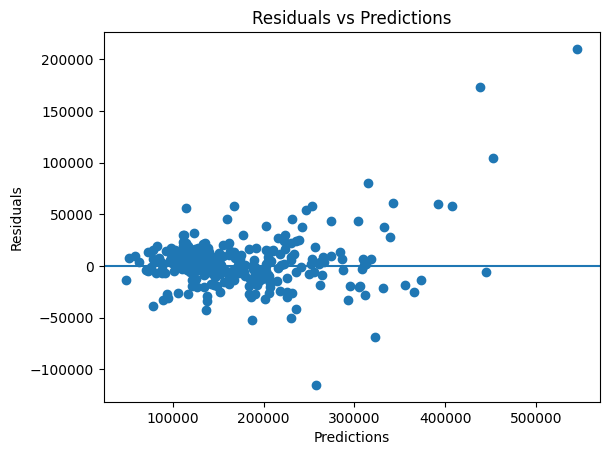

In [25]:
# visualization of interaction Residuals and Predictions
residuals = y_valid - y_pred
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

**Residuals vs Predictions** — There is clear heteroscedasticity: the more expensive the house, the larger the error variance. Several outliers with residuals above 150k significantly increase the RMSE.

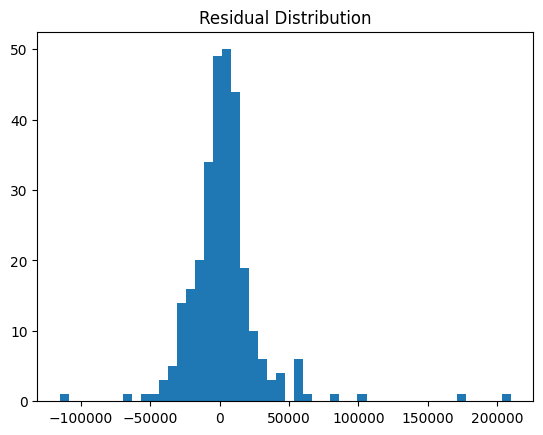

In [26]:
plt.figure()
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

**Residual Distribution** — The distribution is centered around zero, but there is a right tail up to +200k. The model underestimates prices more often than it overestimates them.

***Conclusion:*** The model performs well in the middle segment, but poorly in the high-price segment.